In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
df = pd.read_excel('PS 1.xlsx')
df.head()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,DensityRatio,BoundaryLength,VariantLabel
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [ ]:
# Feature Type
# The dataset primarily consists of continuous numerical features with one categorical label.
df.dtypes

,0
PixelMass,int64
LongAxisSpan,float64
ShortAxisSpan,float64
ShapeDeviation,float64
HullMass,int64
DensityRatio,float64
BoundaryLength,float64
VariantLabel,object


In [ ]:
# Feature Ranges & Statistical Summary

df.describe()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,DensityRatio,BoundaryLength
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [ ]:
# Scale Imbalance Detection

range_vals = df.describe().loc['max'] - df.describe().loc['min']
range_vals

,0
PixelMass,209660.000000
LongAxisSpan,771.662400
ShortAxisSpan,348.564407
ShapeDeviation,0.613395
HullMass,252078.000000
DensityRatio,0.455598
BoundaryLength,2078.679000


PixelMass, HullMass → very large scale

DensityRatio, ShapeDeviation → very small scale

1 (b) Construct multi-perspective visualizations:

Distribution plots (univariate)

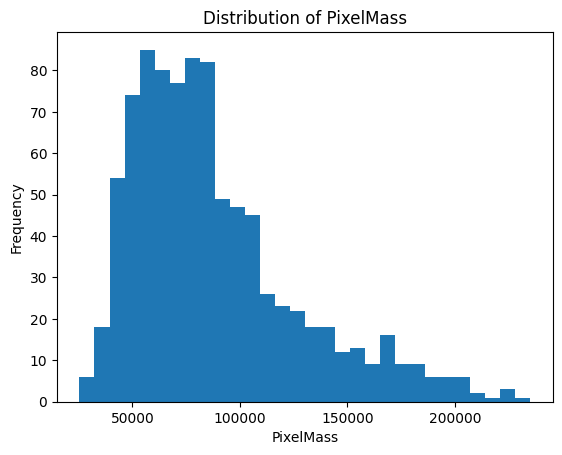

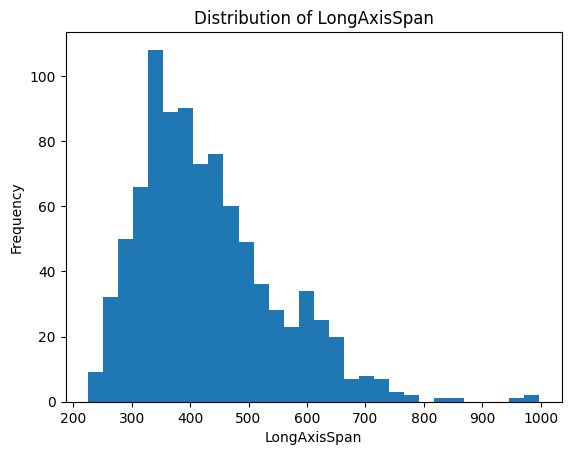

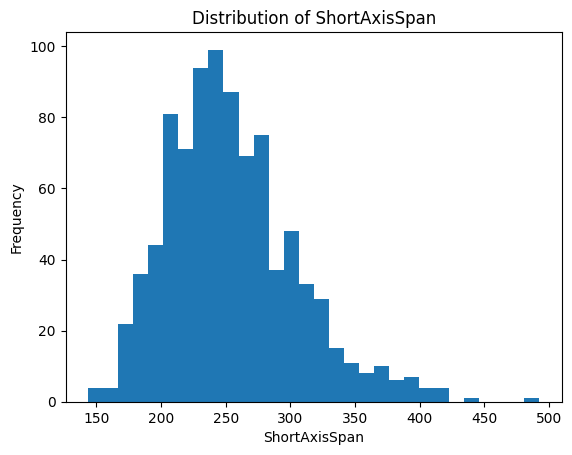

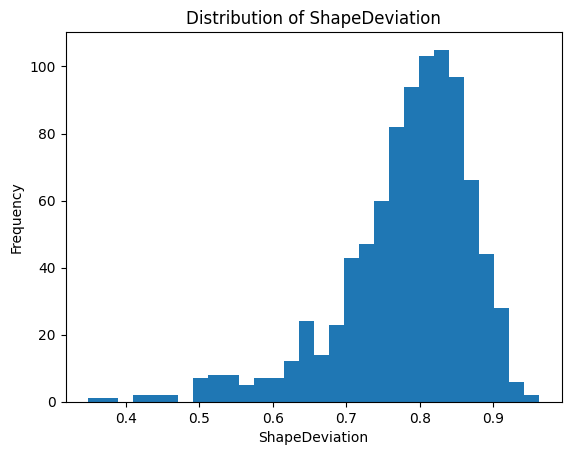

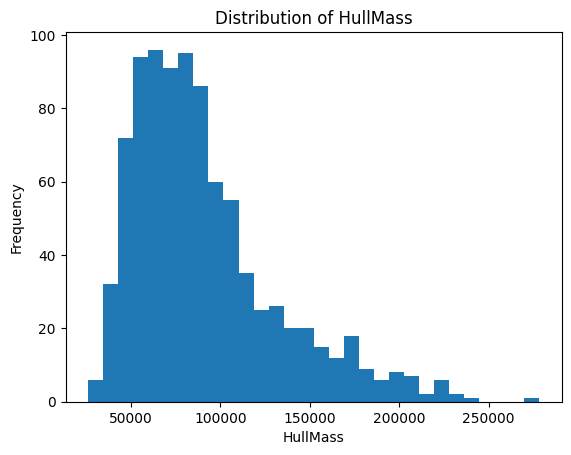

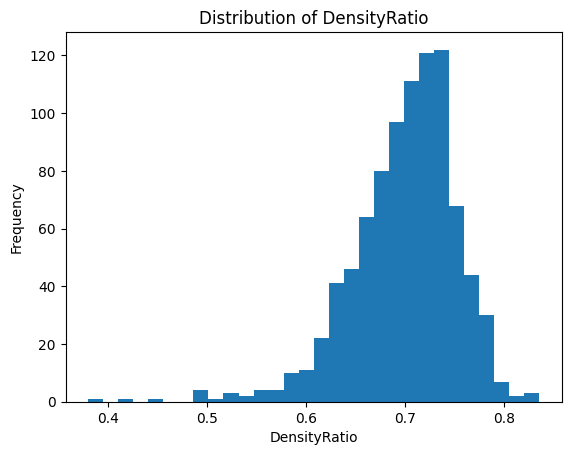

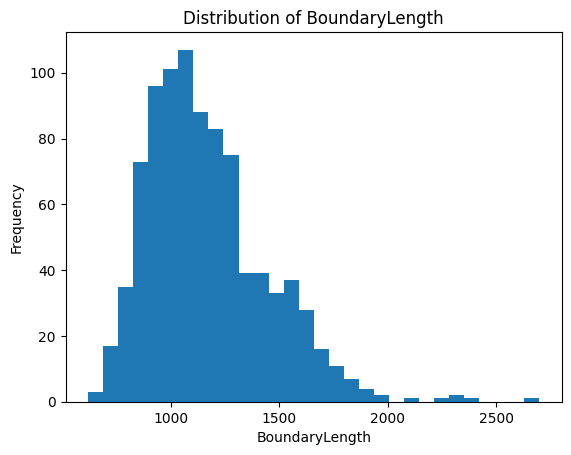

In [ ]:
# Plot histograms for all numeric features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

1(b) part 2  Pairwise relationships (bivariate)

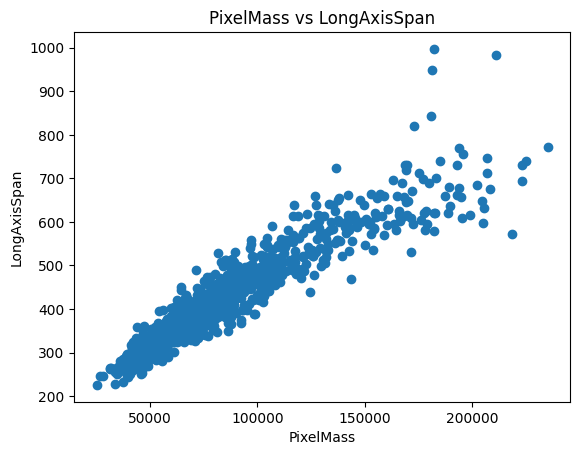

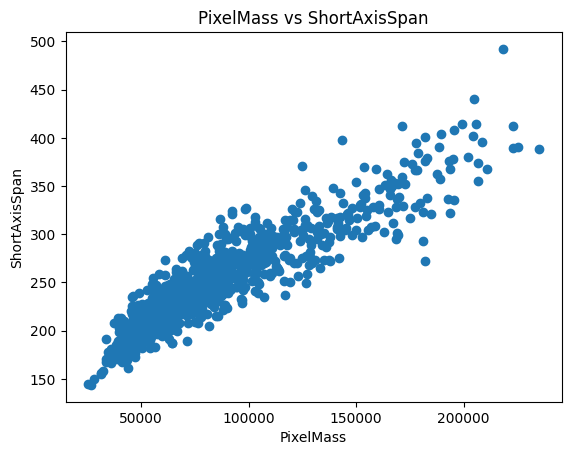

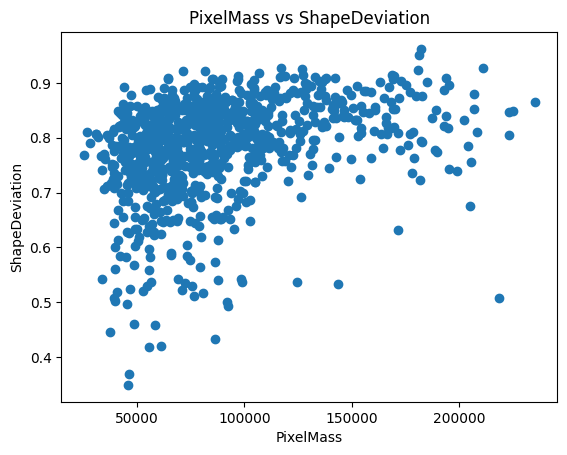

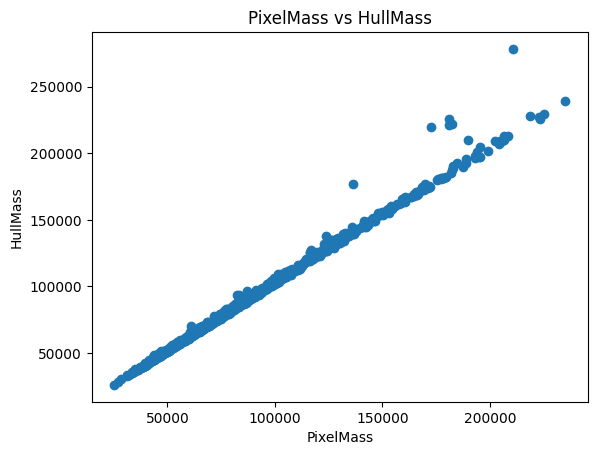

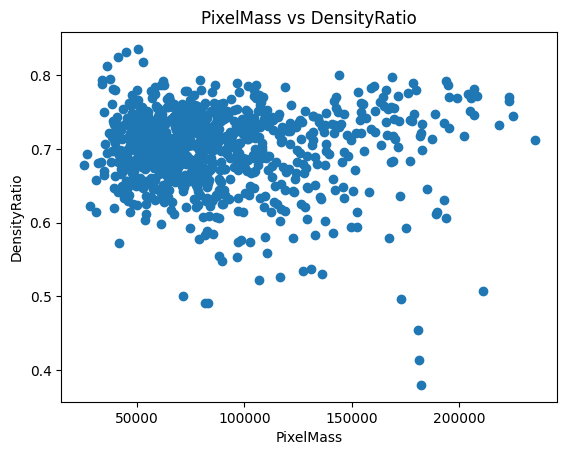

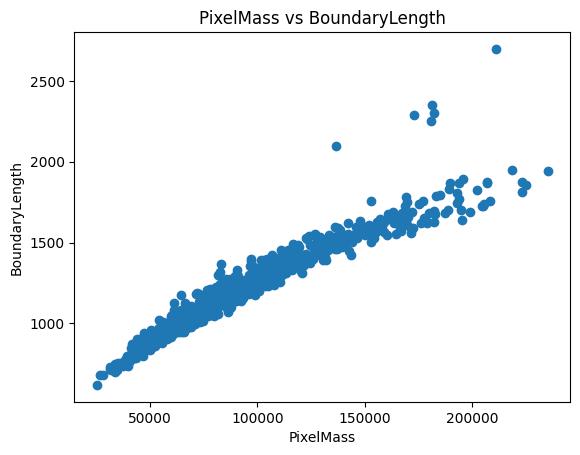

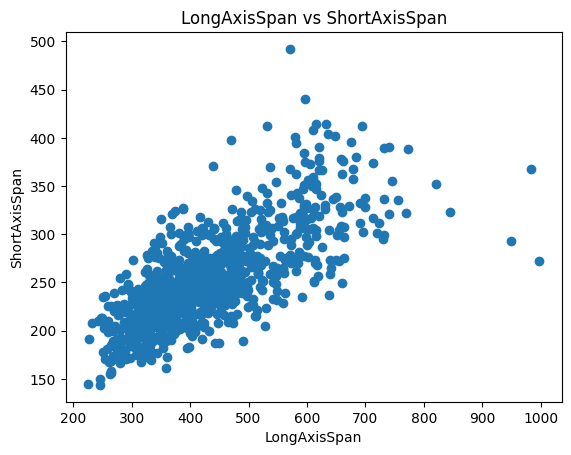

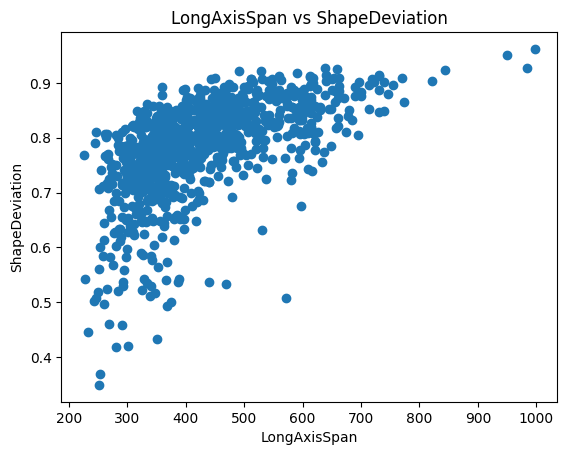

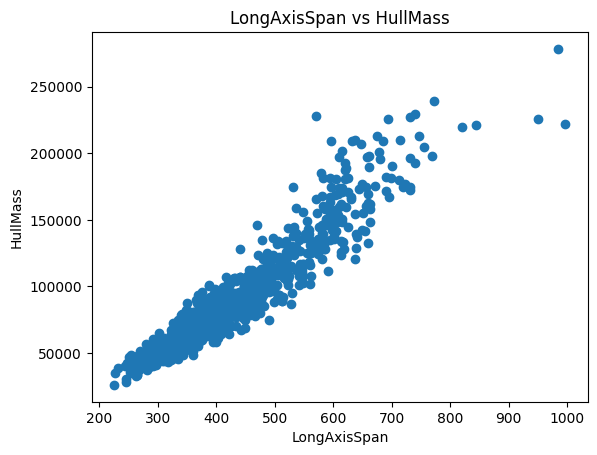

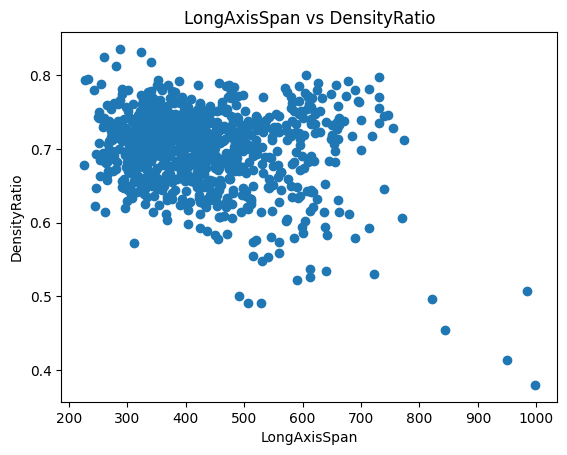

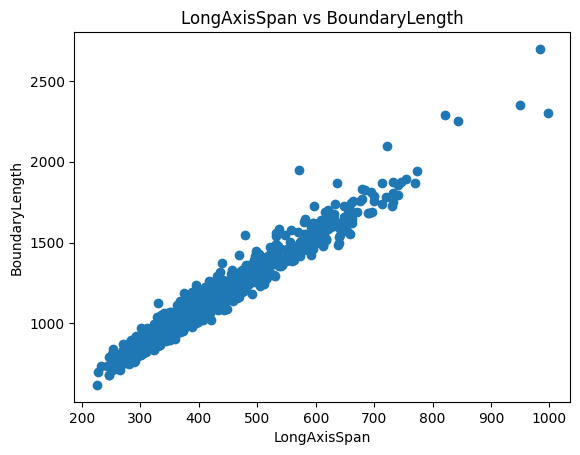

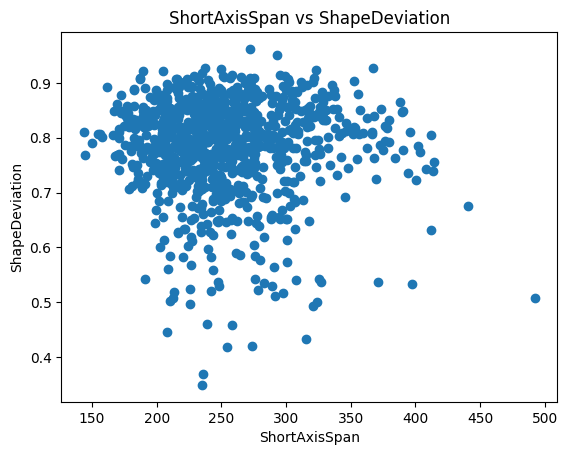

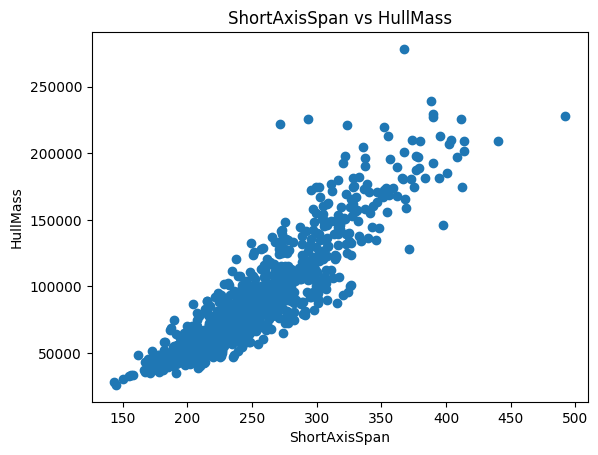

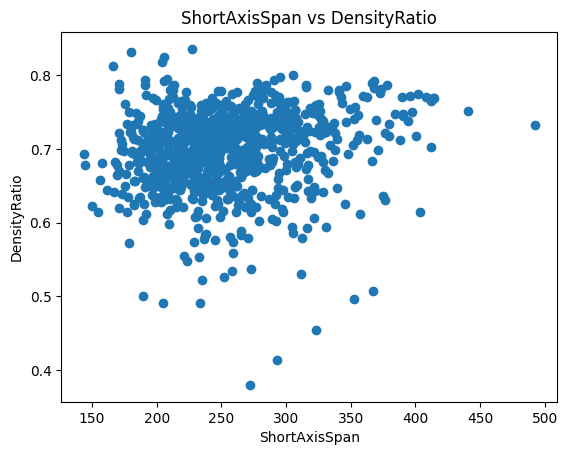

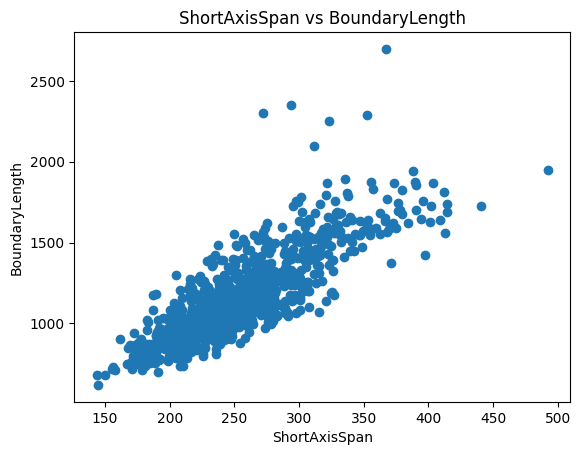

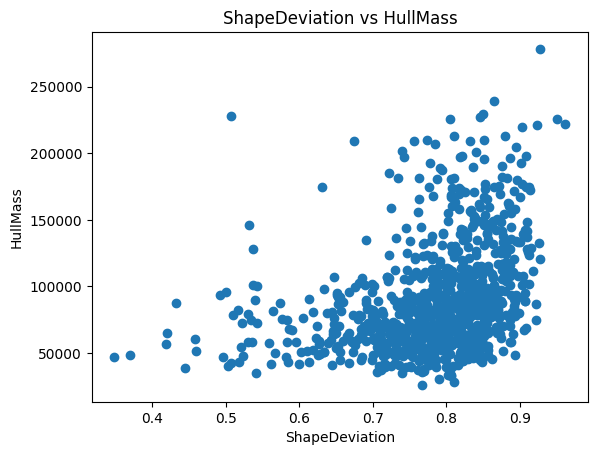

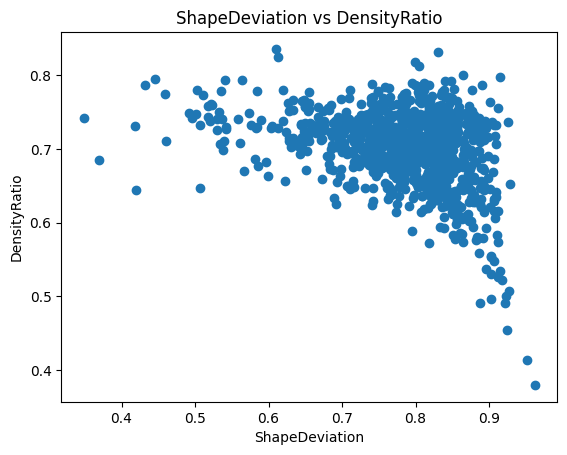

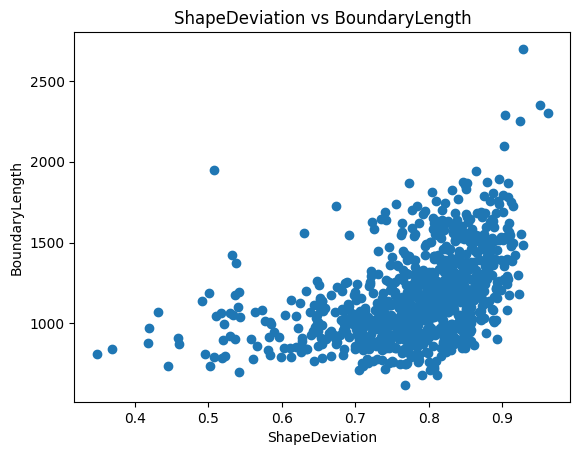

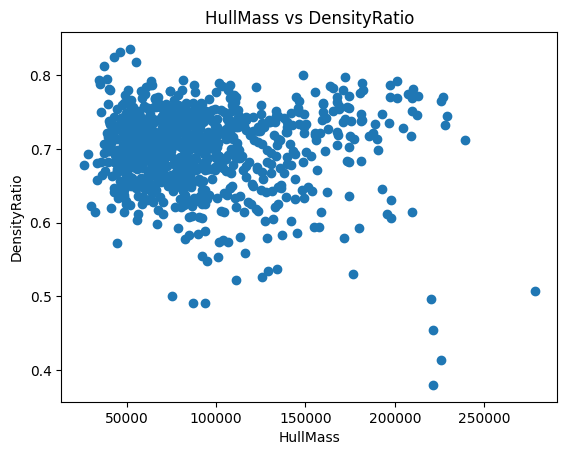

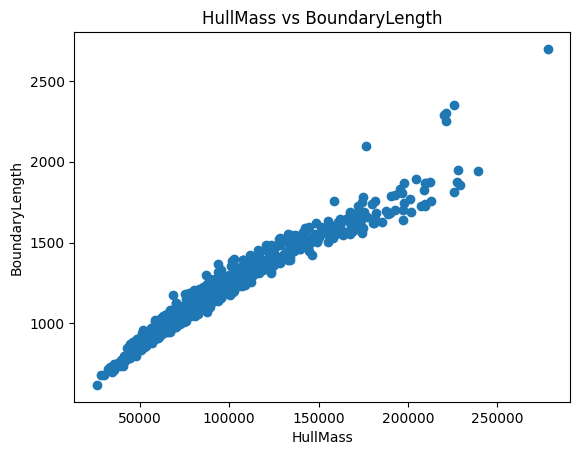

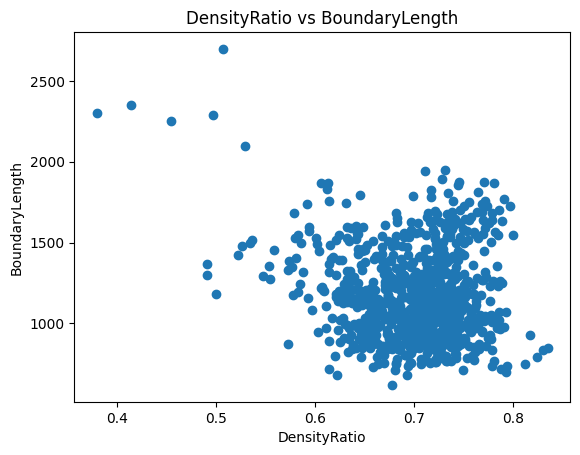

In [ ]:
# Plot pairwise scatter (limited for readability)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns


for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        plt.figure()
        plt.scatter(df[numeric_cols[i]], df[numeric_cols[j]])
        plt.xlabel(numeric_cols[i])
        plt.ylabel(numeric_cols[j])
        plt.title(f"{numeric_cols[i]} vs {numeric_cols[j]}")
        plt.show()

Class-conditional feature distributions

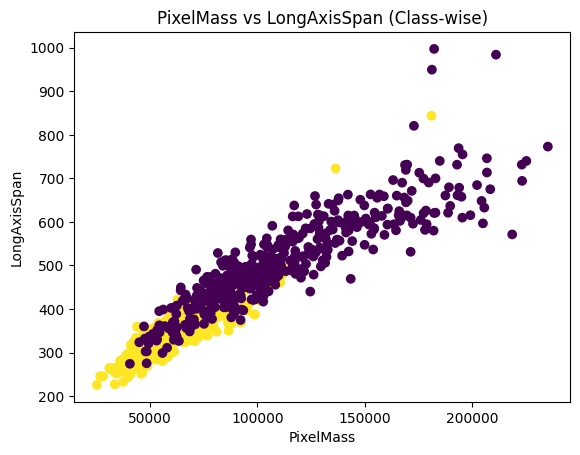

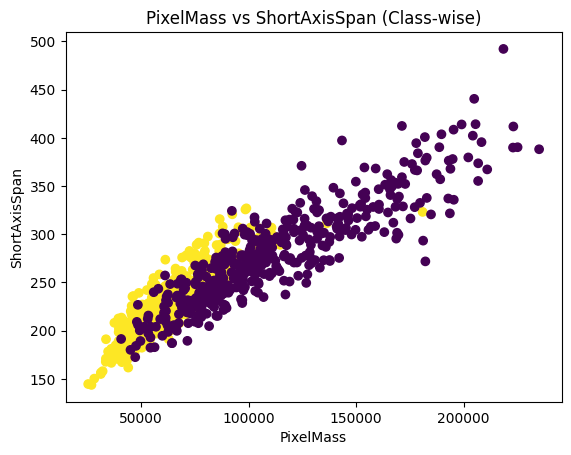

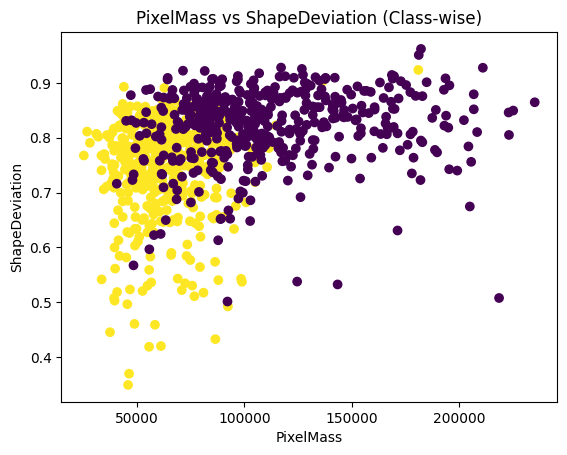

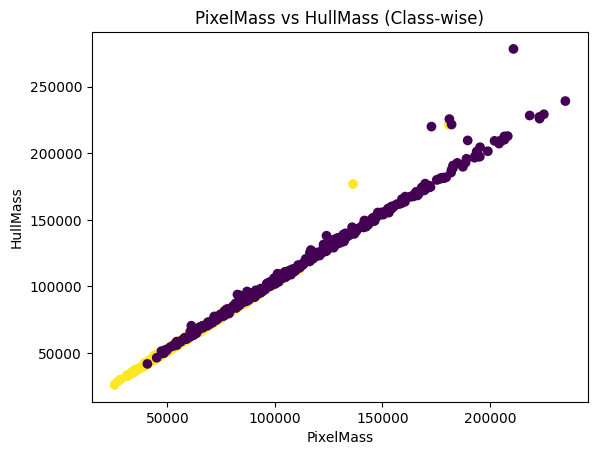

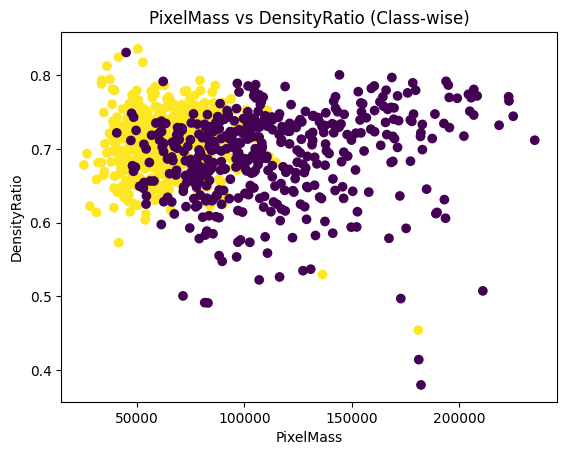

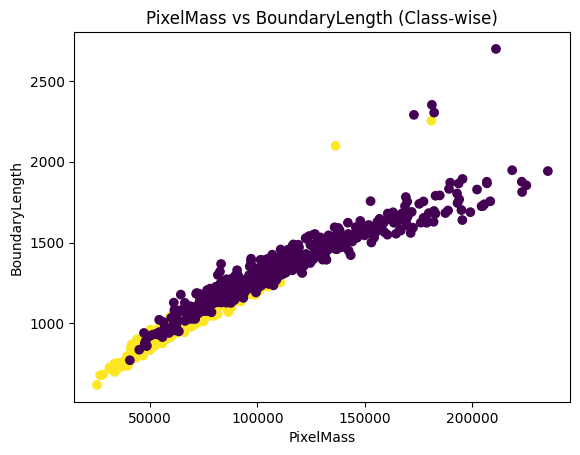

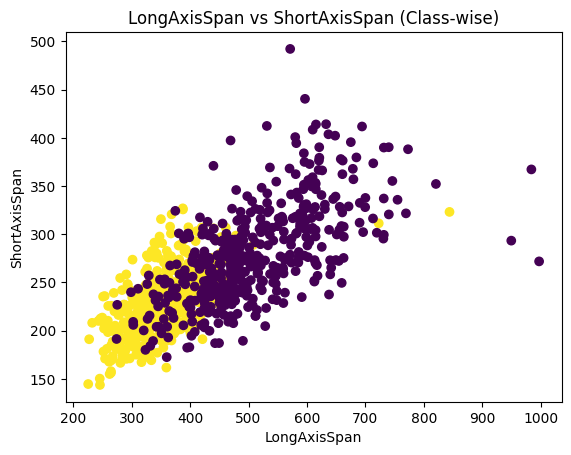

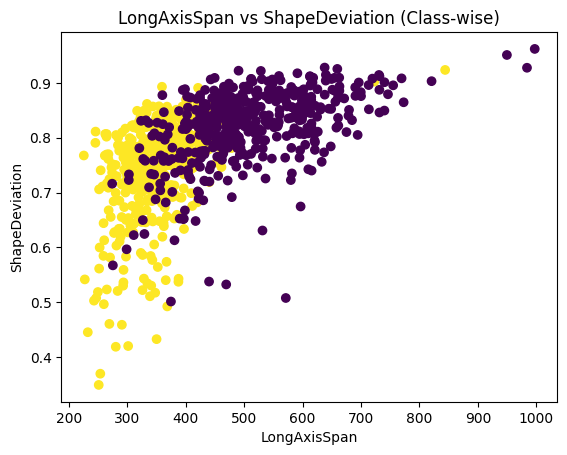

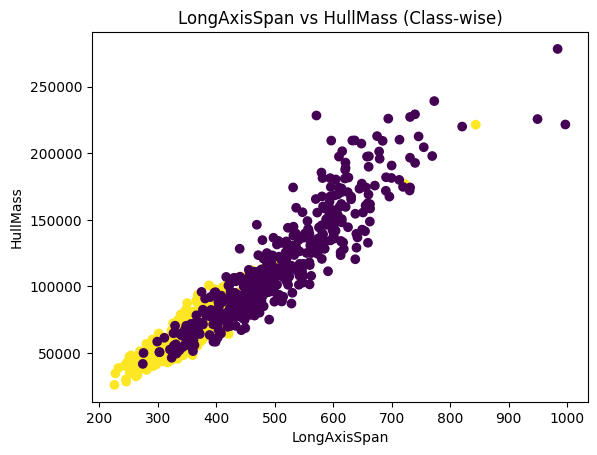

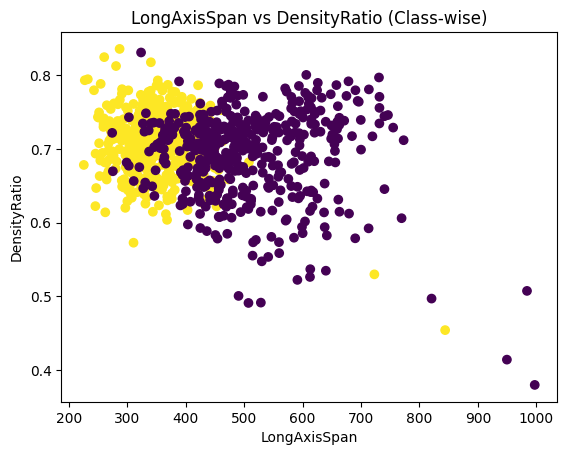

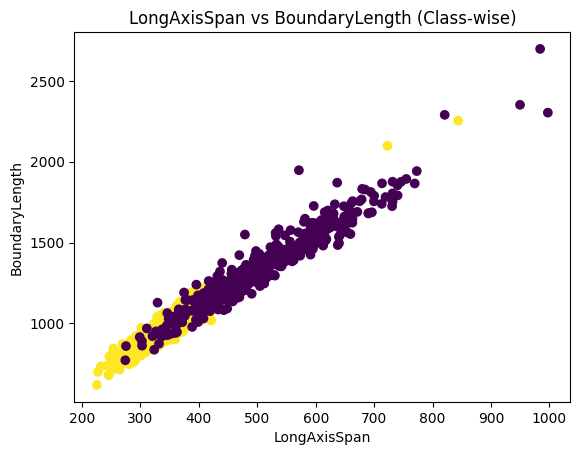

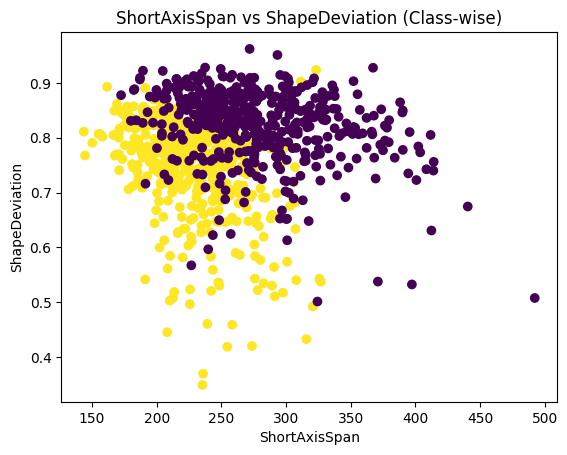

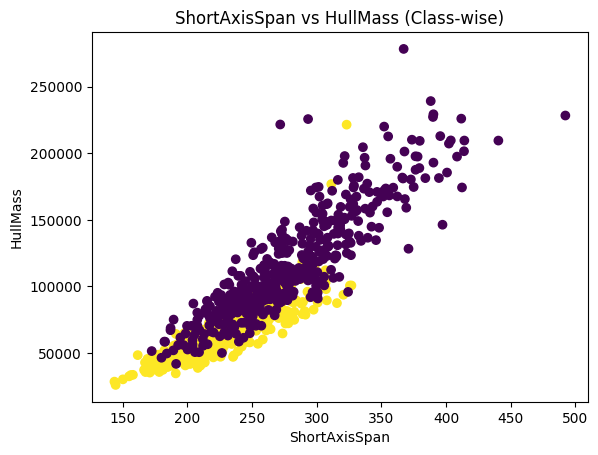

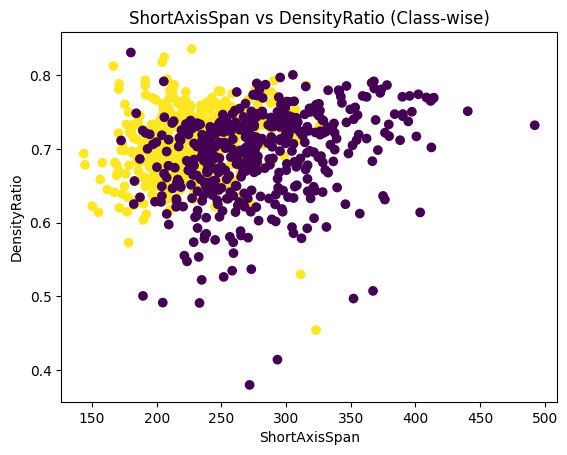

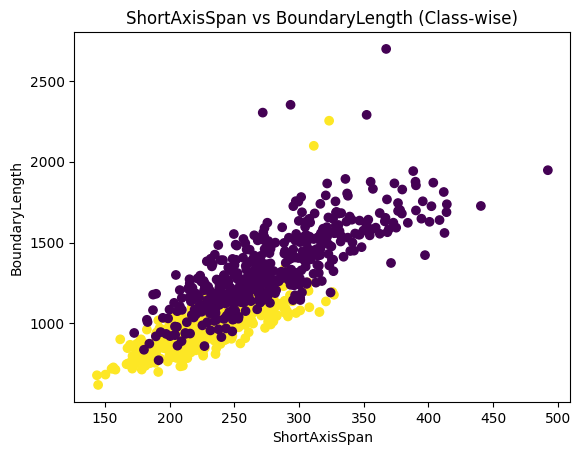

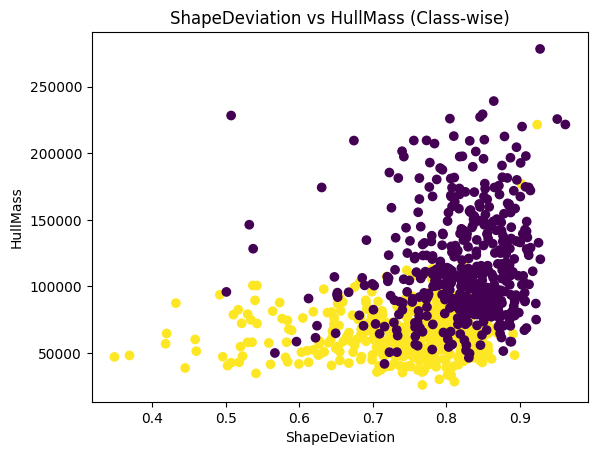

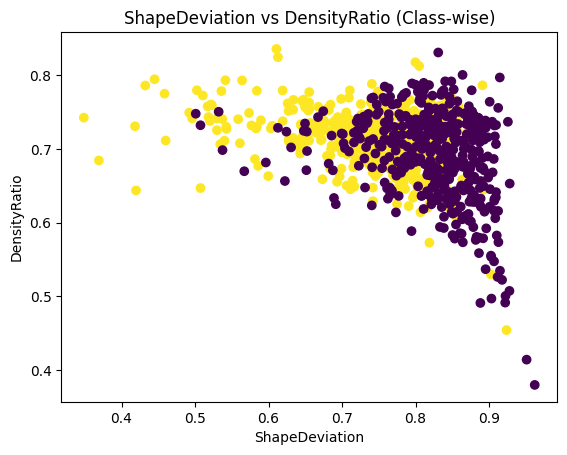

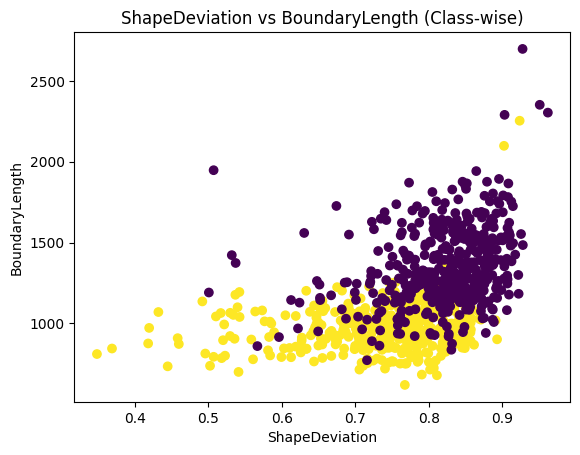

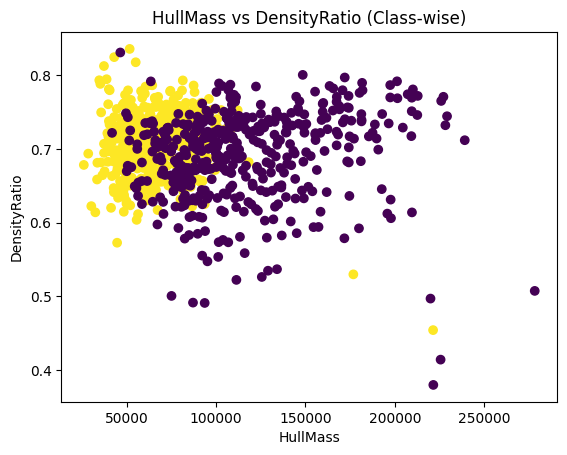

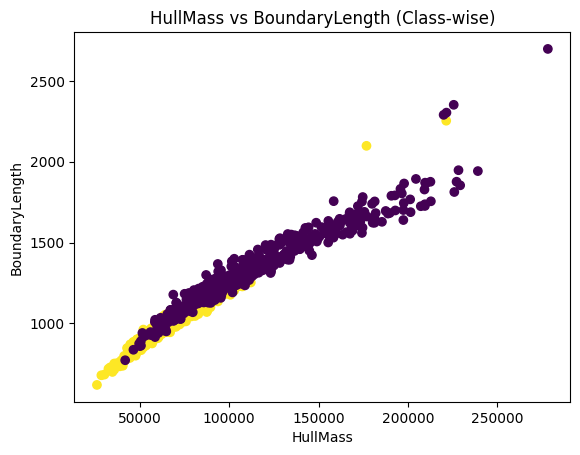

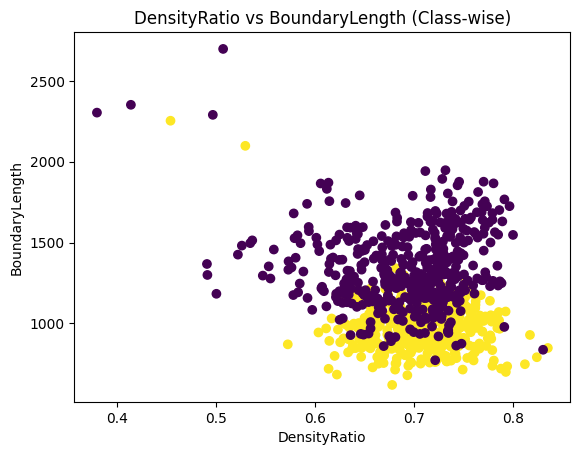

In [ ]:
# Encode class for coloring
labels = df['VariantLabel'].astype('category').cat.codes

for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        plt.figure()
        plt.scatter(df[numeric_cols[i]], df[numeric_cols[j]], c=labels)
        plt.xlabel(numeric_cols[i])
        plt.ylabel(numeric_cols[j])
        plt.title(f"{numeric_cols[i]} vs {numeric_cols[j]} (Class-wise)")
        plt.show()

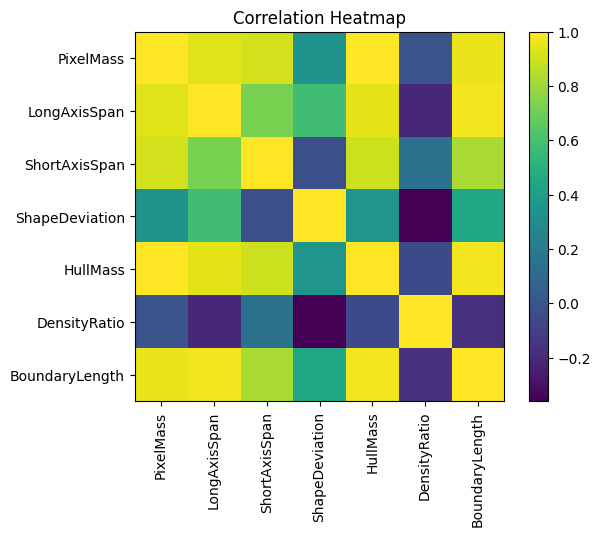

In [ ]:
corr = df[numeric_cols].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()